# Practice Project: Memory-Based Chatbot

Build a chatbot using **LangGraph** that remembers previous messages during a conversation.

Use **state, reducers, message history, and checkpointing** to maintain conversation memory and allow the chatbot to answer questions based on earlier messages.

In [35]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from dotenv import load_dotenv

# import for reducer
from operator import add 
from typing import TypedDict, Annotated

# import for memory
from langgraph.checkpoint.memory import InMemorySaver


In [36]:
load_dotenv()

True

In [37]:
from pydantic import BaseModel

class LLMResponseSchema(BaseModel):
    answer: str

In [38]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    temperature=0
)

# llm = llm.with_structured_output(LLMResponseSchema)

# Reducer in LangGraph

A **reducer** defines how LangGraph should combine a new state update with the existing state value.

### Example

```python
from typing import Annotated, TypedDict
from operator import add
from langchain_core.messages import BaseMessage

class StateSchema(TypedDict):
    messages: Annotated[list[BaseMessage], add]
```

Here:

- messages → stores the conversation history.
- Annotated[..., add] → tells LangGraph to use add as the reducer.
- add combines the existing messages with new messages instead of replacing them.

#### Example
- Existing state:  messages = [HumanMessage("Hi")]
- Node returns: messages = [AIMessage("Hello!")]

Reducer combines them:
```python
messages = [
    HumanMessage("Hi"),
    AIMessage("Hello!")
]
```

## What happen if I don't use Reducer ?
**Without a reducer, a new messages update would replace the previous messages.**

Example:
- Existing state:  messages = [HumanMessage("Hi")] 
```python
messages = [
    HumanMessage("Hi")
]
```

- Node returns: messages = [AIMessage("Hello!")]

```python
messages = [
    AIMessage("Hello!")
]
```

In [39]:
class StateSchema(TypedDict):
    messages: Annotated[list[BaseMessage], add]


In [40]:
def llm_chat(state: StateSchema):

    # get all the previous chat messages from current
    msgs = state["messages"]

    # send all the chat messages of current thread to llm
    resp = llm.invoke(msgs)

    return { "messages": [resp] }

In [59]:
graph = StateGraph(StateSchema)

graph.add_node("llm_chat", llm_chat)


graph.add_edge(START, "llm_chat")
graph.add_edge("llm_chat", END)

# define memory 
memory = InMemorySaver()

# compile flow with memory 
workflow = graph.compile(checkpointer=memory)

# InMemorySaver in LangGraph

`InMemorySaver` is a **checkpointer** used to save and restore LangGraph state in memory.

### Example

```python
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

workflow = graph.compile(checkpointer=memory)
```

## Thread ID

Use a thread_id to maintain separate conversation states:
```python
config = {
    "configurable": {
        "thread_id": "user-1"
    }
}
```

The same thread_id allows the chatbot to access previous conversation state.

Important
Useful for development and testing.
State is stored in application memory.
Restarting the application clears the memory.
For production, use a persistent checkpointer/database.

In short: InMemorySaver = temporary state persistence for LangGraph workflows.


In [55]:
config = {
    "configurable": {
        "thread_id": "user-1"
    }
}

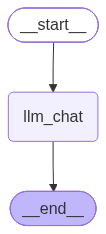

In [56]:
workflow

In [61]:
# chat bot
while(True):
    msg = input()

    if msg.strip().lower() in ["quit", "bye", "exit"]:
        break

    humanMessage = HumanMessage(content=msg)
    resp = workflow.invoke({"messages": [humanMessage]}, config)

    print(resp)

    # for msg in resp["messages"]:
    #     print(msg)

    


{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}), AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'index': 0, 'extras': {'signature': 'EnEKbwERTTIPfaqbDZBs6RfmBHkdnvlATr+0luWvp0s28pViD0+Mi3uoUlWH1E8iOkZ0y8vrTSxCAHcvzGo66cf/cmgMVzDe55Pe+6EJlBvWYakRnhilsj8FnF6zjq3rI/vQgGQhSJDK7MtXE25J7PNOiA=='}}], additional_kwargs={}, response_metadata={'safety_ratings': [], 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'model_provider': 'google_genai'}, id='lc_run--01a00ac2-5ebb-7260-ba11-7447a60ed731', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 9, 'total_tokens': 11, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='hello', additional_kwargs={}, response_metadata={}), AIMessage(content=[{'type': 'text', 'text': 'Hello again! How are you doing today? Is there anything I can help you with?', 'extras': {'signature': 'EnEKbwERTTIP5vX8BotwfO122w/7qGT253+ETr

In [ ]:


memory.get({
        "configurable": {
            "thread_id": "user-1"
        }
    })["channel_values"]["messages"]



[HumanMessage(content='', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='hello', additional_kwargs={}, response_metadata={}),
 AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'EnEKbwERTTIP2bKndQY1oRkqYxlFYL6agn5DQBGClbr+P95EzOUb3eNZQlvc6iMOMDFa711W5TJp7ecUJqljBIvZunxO5Id9k8FF0b9VLplCTC35S84QT6K3yeAGZPFV9Sp1uoqaIxaGw1RrZ9n2t36pqA=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a00a9e-370e-7063-a6a2-2f2c6eefb475-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 9, 'total_tokens': 11, 'input_token_details': {'cache_read': 0}}),
 HumanMessage(content='my name is bhavin', additional_kwargs={}, response_metadata={}),
 AIMessage(content=[{'type': 'text', 'text': "It's nice to meet you, Bhavin! How are you doing today? Is there anything I can

In [ ]:
import time
while True:

    msg = input()

    if msg.strip().lower() in ["quit", "bye", "exit"]:
        break

    config = {
        "configurable": {
            "thread_id": "user-1"
        }
    }

    humanMessage = HumanMessage(content=msg)

    # stream response 
    # instead of calling: workflow.invoke() 
    # we need to call workflow.stream(initial state, stream_mode, config, version) -> @return generator iterator
    # iterator -> message and metadata
    # we need to iterate throgh it and print the response

    streamGenerator = workflow.stream(
        {"messages": [humanMessage]},
        stream_mode="messages",
        version="v2",
        config=config
    )

    for chunk in streamGenerator:
        message, metadata = chunk["data"]

        if isinstance(message.content, list):
            for content in message.content:
                if content.get("type") == "text":
                    print(content["text"], end="", flush=True)
                    time.sleep(0.1)
        elif message.content:
            print(message.content, end="", flush=True)

    print()


Hello! How can I help you today?
